In [16]:
import scanpy as sc
import pandas as pd
import anndata as ad
import re

In [17]:
adata = sc.read_h5ad("../data/uhm-et-al-2025/combined_dataset.h5ad")
adata

AnnData object with n_obs × n_vars = 557908 × 32738
    obs: 'sample', 'n_genes', 'n_counts'
    var: 'n_cells'

In [18]:
adata.obs['sample'].value_counts()

sample
GSM5293862_D9     29907
GSM5293851_B2     27531
GSM5293860_D1     27056
GSM5293867_E3     26644
GSM5293870_N1     26171
GSM5293846_A2     26021
GSM5293872_N3     24887
GSM5293848_A7     24074
GSM5293864_D13    22489
GSM5293854_B8     21584
GSM5293871_N2     21480
GSM5293874_N5     21018
GSM5293868_E4     20304
GSM5293861_D8     19997
GSM5293857_C3     18279
GSM5293866_E2     18184
GSM5293856_C2     17496
GSM5293853_B5     16668
GSM5293865_E1     15607
GSM5293845_A1     15019
GSM5293863_D10    14988
GSM5293858_C4     14532
GSM5293855_C1     13684
GSM5293849_A8     13601
GSM5293850_B1     13157
GSM5293852_B4     12987
GSM5293859_C7     12061
GSM5293869_E5      9875
GSM5293873_N4      8887
GSM5293847_A3      3720
Name: count, dtype: int64

In [19]:
# Create a boolean mask for samples ending with A1-5 or N1-5
pattern = r'.*[EN][1-5]$'
mask = adata.obs['sample'].str.match(pattern)

# Filter the data
adata = adata[mask]

In [21]:
adata

View of AnnData object with n_obs × n_vars = 193057 × 32738
    obs: 'sample', 'n_genes', 'n_counts'
    var: 'n_cells'

In [20]:
adata.obs['sample'].value_counts()

sample
GSM5293867_E3    26644
GSM5293870_N1    26171
GSM5293872_N3    24887
GSM5293871_N2    21480
GSM5293874_N5    21018
GSM5293868_E4    20304
GSM5293866_E2    18184
GSM5293865_E1    15607
GSM5293869_E5     9875
GSM5293873_N4     8887
Name: count, dtype: int64

In [22]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

C:\Users\doram\AppData\Local\Temp\ipykernel_5040\148835365.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith("MT-")


In [23]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

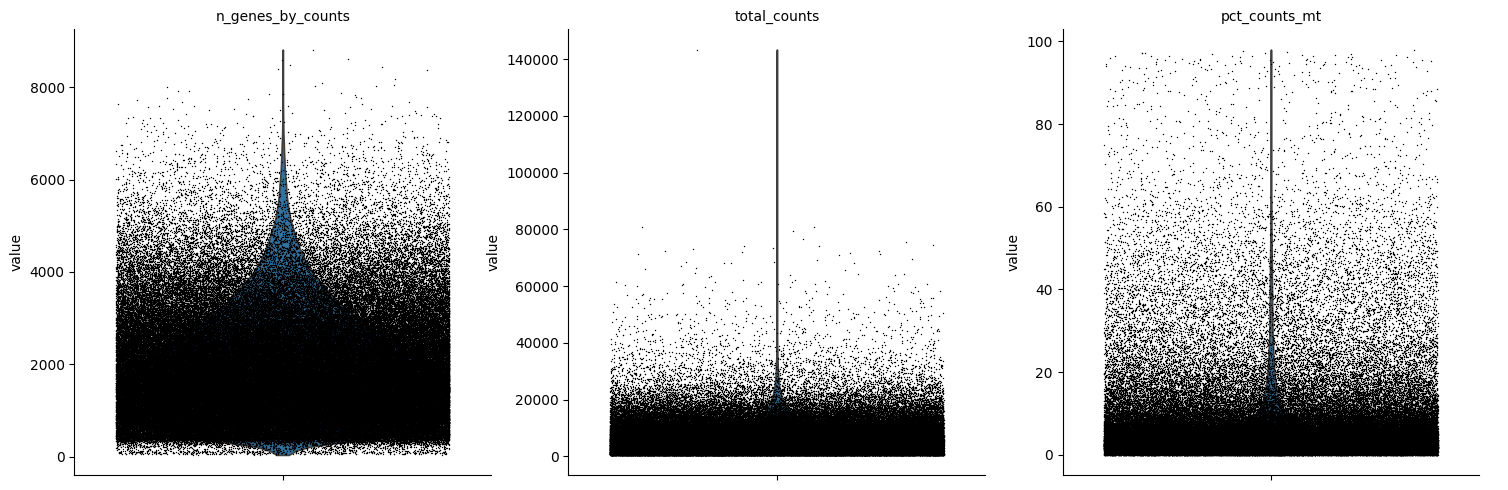

In [24]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

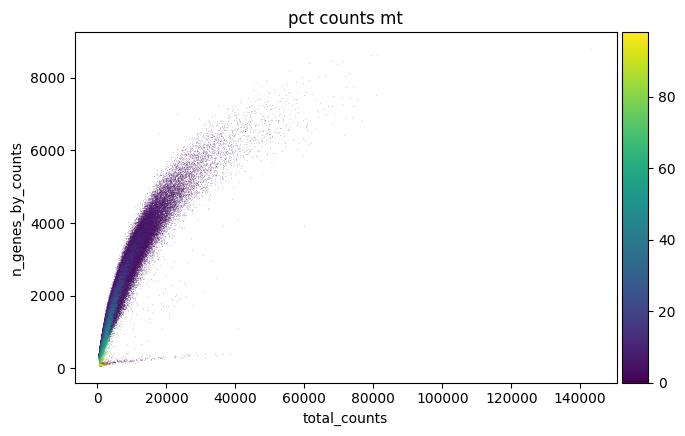

In [26]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [27]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [29]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [31]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

MemoryError: Unable to allocate 1.41 GiB for an array with shape (377532957,) and data type int32